In [1]:
import warnings

import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import seaborn as sn

warnings.simplefilter("ignore")
plt.style.use("ggplot")

# TEOTIL3 for Lillestrøm kommune
# Notebook 04: Estimate annual loads

## 1. Sites of interest

In [2]:
# Read site data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
stn_df = pd.read_excel(xl_path, sheet_name="chem_stns")
stn_df = stn_df[stn_df["comment"].str.startswith("Downstream")]
stn_df

,catchment,station_id,station_name,regine,wb_id,wb_name,lon,lat,comment
0,Sagelva,002-46599,Sagelva ved Skjetten bro (F3),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,11.01695,59.95850,Downstream
2,Nitelva,002-30586,Rud Nitelva (N8),002.CB0,002-3891-R,Nedre Nitelva,11.05700,59.94553,Downstream
4,Leira,002-29659,Leira ved Borgen bru (L5),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.10032,59.95036,Downstream
6,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,002.D2Z,002-3659-R,Rømua,11.22099,60.02163,Downstream
7,Jeksla,002-30593,"Jeksla ved Haugli, J14",002.CAA0,002-599-R,Jeksla,11.10637,60.00199,Downstream. Small part of regine
8,Åa,002-60929,Fossåa ved Sylta (ÅA1),002.D3Z,002-3685-R,Fossåa,11.30018,59.99209,Downstream
11,Gansåa,002-60933,Gansåa nedstrøms Dalen RA (BD),002.C5,002-3655-R,Gansåa,11.22275,59.86139,Downstream. Small part of regine


## 2. Water chemistry data

Use the cleaned and filtered water chemistry data from Notebook 02.

In [3]:
# Chem from Vannmiljø
xl_path = r"../data/cleaned_concs_waterbodies.xlsx"
wc_df = pd.read_excel(xl_path, sheet_name="cleaned_chem")
wc_df.columns = [col.replace("µ", "u") for col in wc_df.columns]
wc_df.head()

,waterbody_id,waterbody_name,sample_date,year,SS_mg/l,TOC_mg/l,TOTN_ug/l,TOTP_ug/l
0,002-1638-R,Nitelva Slattum-Kjeller,1995-01-02,1995,2.9,3.7,950.0,16.0
1,002-1638-R,Nitelva Slattum-Kjeller,1995-01-09,1995,1.4,3.7,1010.0,9.0
2,002-1638-R,Nitelva Slattum-Kjeller,1995-01-16,1995,2.1,3.3,1060.0,10.0
3,002-1638-R,Nitelva Slattum-Kjeller,1995-01-23,1995,3.7,5.4,1520.0,15.0
4,002-1638-R,Nitelva Slattum-Kjeller,1995-01-30,1995,1.6,3.3,1230.0,8.0


## 3. Flow data

Use modelled data from the GTS API. For Sagelva, we also have measured data from the same location as the water chemistry sampling, so we can check to assess the effect of using modelled discharge (at least for this single location) - see Section 6.

In [4]:
# Flows from NVE
xl_path = r"../data/nve_data.xlsx"
gts_df = pd.read_excel(xl_path, sheet_name="gts-api")
nve_df = pd.read_excel(xl_path, sheet_name="hyd-api")
gts_df.head()

,date,002-101949,002-106796,002-106815,002-106818,002-109603,002-109604,002-109608,002-111393,002-112453,...,002-79092,002-79097,002-79557,002-80573,002-81594,002-81595,002-91322,002-94483,002-98385,002-98386
0,1980-01-01,0.998913,0.129389,0.234766,0.233588,0.588398,0.538709,0.324984,2.258290,0.580173,...,2.901668,1.046488,1.749078,3.046249,3.087813,5.773402,0.067665,0.069442,1.580484,1.629586
1,1980-01-02,0.920197,0.126014,0.227687,0.226545,0.562034,0.513900,0.319262,2.149286,0.553964,...,2.723901,0.967863,1.660796,2.852126,2.905301,5.484510,0.064337,0.067932,1.502468,1.553539
2,1980-01-03,0.845916,0.119263,0.220609,0.219502,0.546455,0.498542,0.315829,2.068717,0.538477,...,2.544283,0.891453,1.609298,2.676668,2.720926,5.213396,0.062118,0.063403,1.441939,1.493788
3,1980-01-04,0.788265,0.118138,0.218249,0.217155,0.540463,0.492635,0.308963,2.004736,0.532520,...,2.412810,0.833868,1.554123,2.538541,2.573799,5.004504,0.061009,0.063403,1.393516,1.436752
4,1980-01-05,0.751679,0.115888,0.217070,0.215981,0.530876,0.484365,0.305531,1.990518,0.522990,...,2.320223,0.797324,1.541248,2.435880,2.465781,4.880058,0.059900,0.063403,1.366614,1.412308


## 4. Estimate annual loads

Using the OSPAR method (the same method used for Elveovervåkingsprogrammet).

In [5]:
val_cols = [
    "TOTN_ug/l",
    "TOTP_ug/l",
    "SS_mg/l",
    "TOC_mg/l",
]
df_list = []
for idx, row in stn_df.iterrows():
    wb_id = row["wb_id"]
    stn_id = row["station_id"]
    wb_wc_df = (
        wc_df.query("waterbody_id == @wb_id")
        .set_index("sample_date")[val_cols]
        .sort_index()
    )
    q_df = gts_df.set_index("date")[[stn_id]]
    q_df.columns = ["flow_m3/s"]

    # Calculate loads
    lds_df = (
        nivapy.stats.estimate_fluxes(
            q_df,
            wb_wc_df,
            base_freq="D",
            agg_freq="YE",
            method="ospar_annual",
            st_date=None,
            end_date=None,
            plot_fold=None,
        )
        .dropna(how="all")
        .reset_index()
    )

    # Convert to tonnes
    cols = [col for col in lds_df.columns if col.endswith("_kg")]
    lds_df[cols] = lds_df[cols] / 1000
    cols = [col.replace("kg", "tonn") for col in lds_df.columns]
    lds_df.columns = cols
    lds_df = lds_df.reset_index()
    lds_df["waterbody_id"] = wb_id
    lds_df = lds_df[
        ["waterbody_id", "year"]
        + [col for col in lds_df.columns if col.endswith("_tonn")]
    ]
    df_list.append(lds_df)
lds_df = pd.concat(df_list, axis="rows")
lds_df.head()

,waterbody_id,year,TOTN_tonn,TOTP_tonn,SS_tonn,TOC_tonn
0,002-3899-R,1995,43.201374,1.261320,430.532291,176.885239
1,002-3899-R,1996,42.329754,1.085266,384.791561,143.628876
2,002-3899-R,1997,30.788682,1.162052,428.468812,128.667945
3,002-3899-R,1998,36.944484,1.682400,637.184286,175.929176
4,002-3899-R,1999,60.889153,3.273468,1481.663014,332.185908


## 5. Tests for trends

Using Mann-Kendall and Sen's slope.

,catchment,wb_id,wb_name,par,mk_trend,mk_pval,sslp,sslp_ub,sslp_lb
0,Leira,002-3384-R,Leira nedstrøms Krokfoss,TOTN_tonn,no trend,0.216860,1.883447,4.762377,-0.895177
1,Leira,002-3384-R,Leira nedstrøms Krokfoss,TOTP_tonn,no trend,0.167145,-0.372421,0.119888,-0.885782
2,Leira,002-3384-R,Leira nedstrøms Krokfoss,SS_tonn,no trend,0.089882,-317.810945,42.853016,-801.107876
3,Leira,002-3384-R,Leira nedstrøms Krokfoss,TOC_tonn,increasing,0.005814,32.338342,51.242282,7.667462
4,Gansåa,002-3655-R,Gansåa,TOTN_tonn,no trend,0.901539,-0.049609,3.447310,-1.841231
5,Gansåa,002-3655-R,Gansåa,TOTP_tonn,no trend,0.536187,0.018424,0.145082,-0.120423
6,Gansåa,002-3655-R,Gansåa,SS_tonn,no trend,0.536187,14.822809,72.576224,-44.493247
7,Gansåa,002-3655-R,Gansåa,TOC_tonn,no trend,0.710523,5.789699,45.945423,-28.300592
8,Rømua,002-3659-R,Rømua,TOTN_tonn,no trend,0.711571,0.790943,4.060211,-2.513297
9,Rømua,002-3659-R,Rømua,TOTP_tonn,no trend,0.341718,0.163585,0.333379,-0.210911


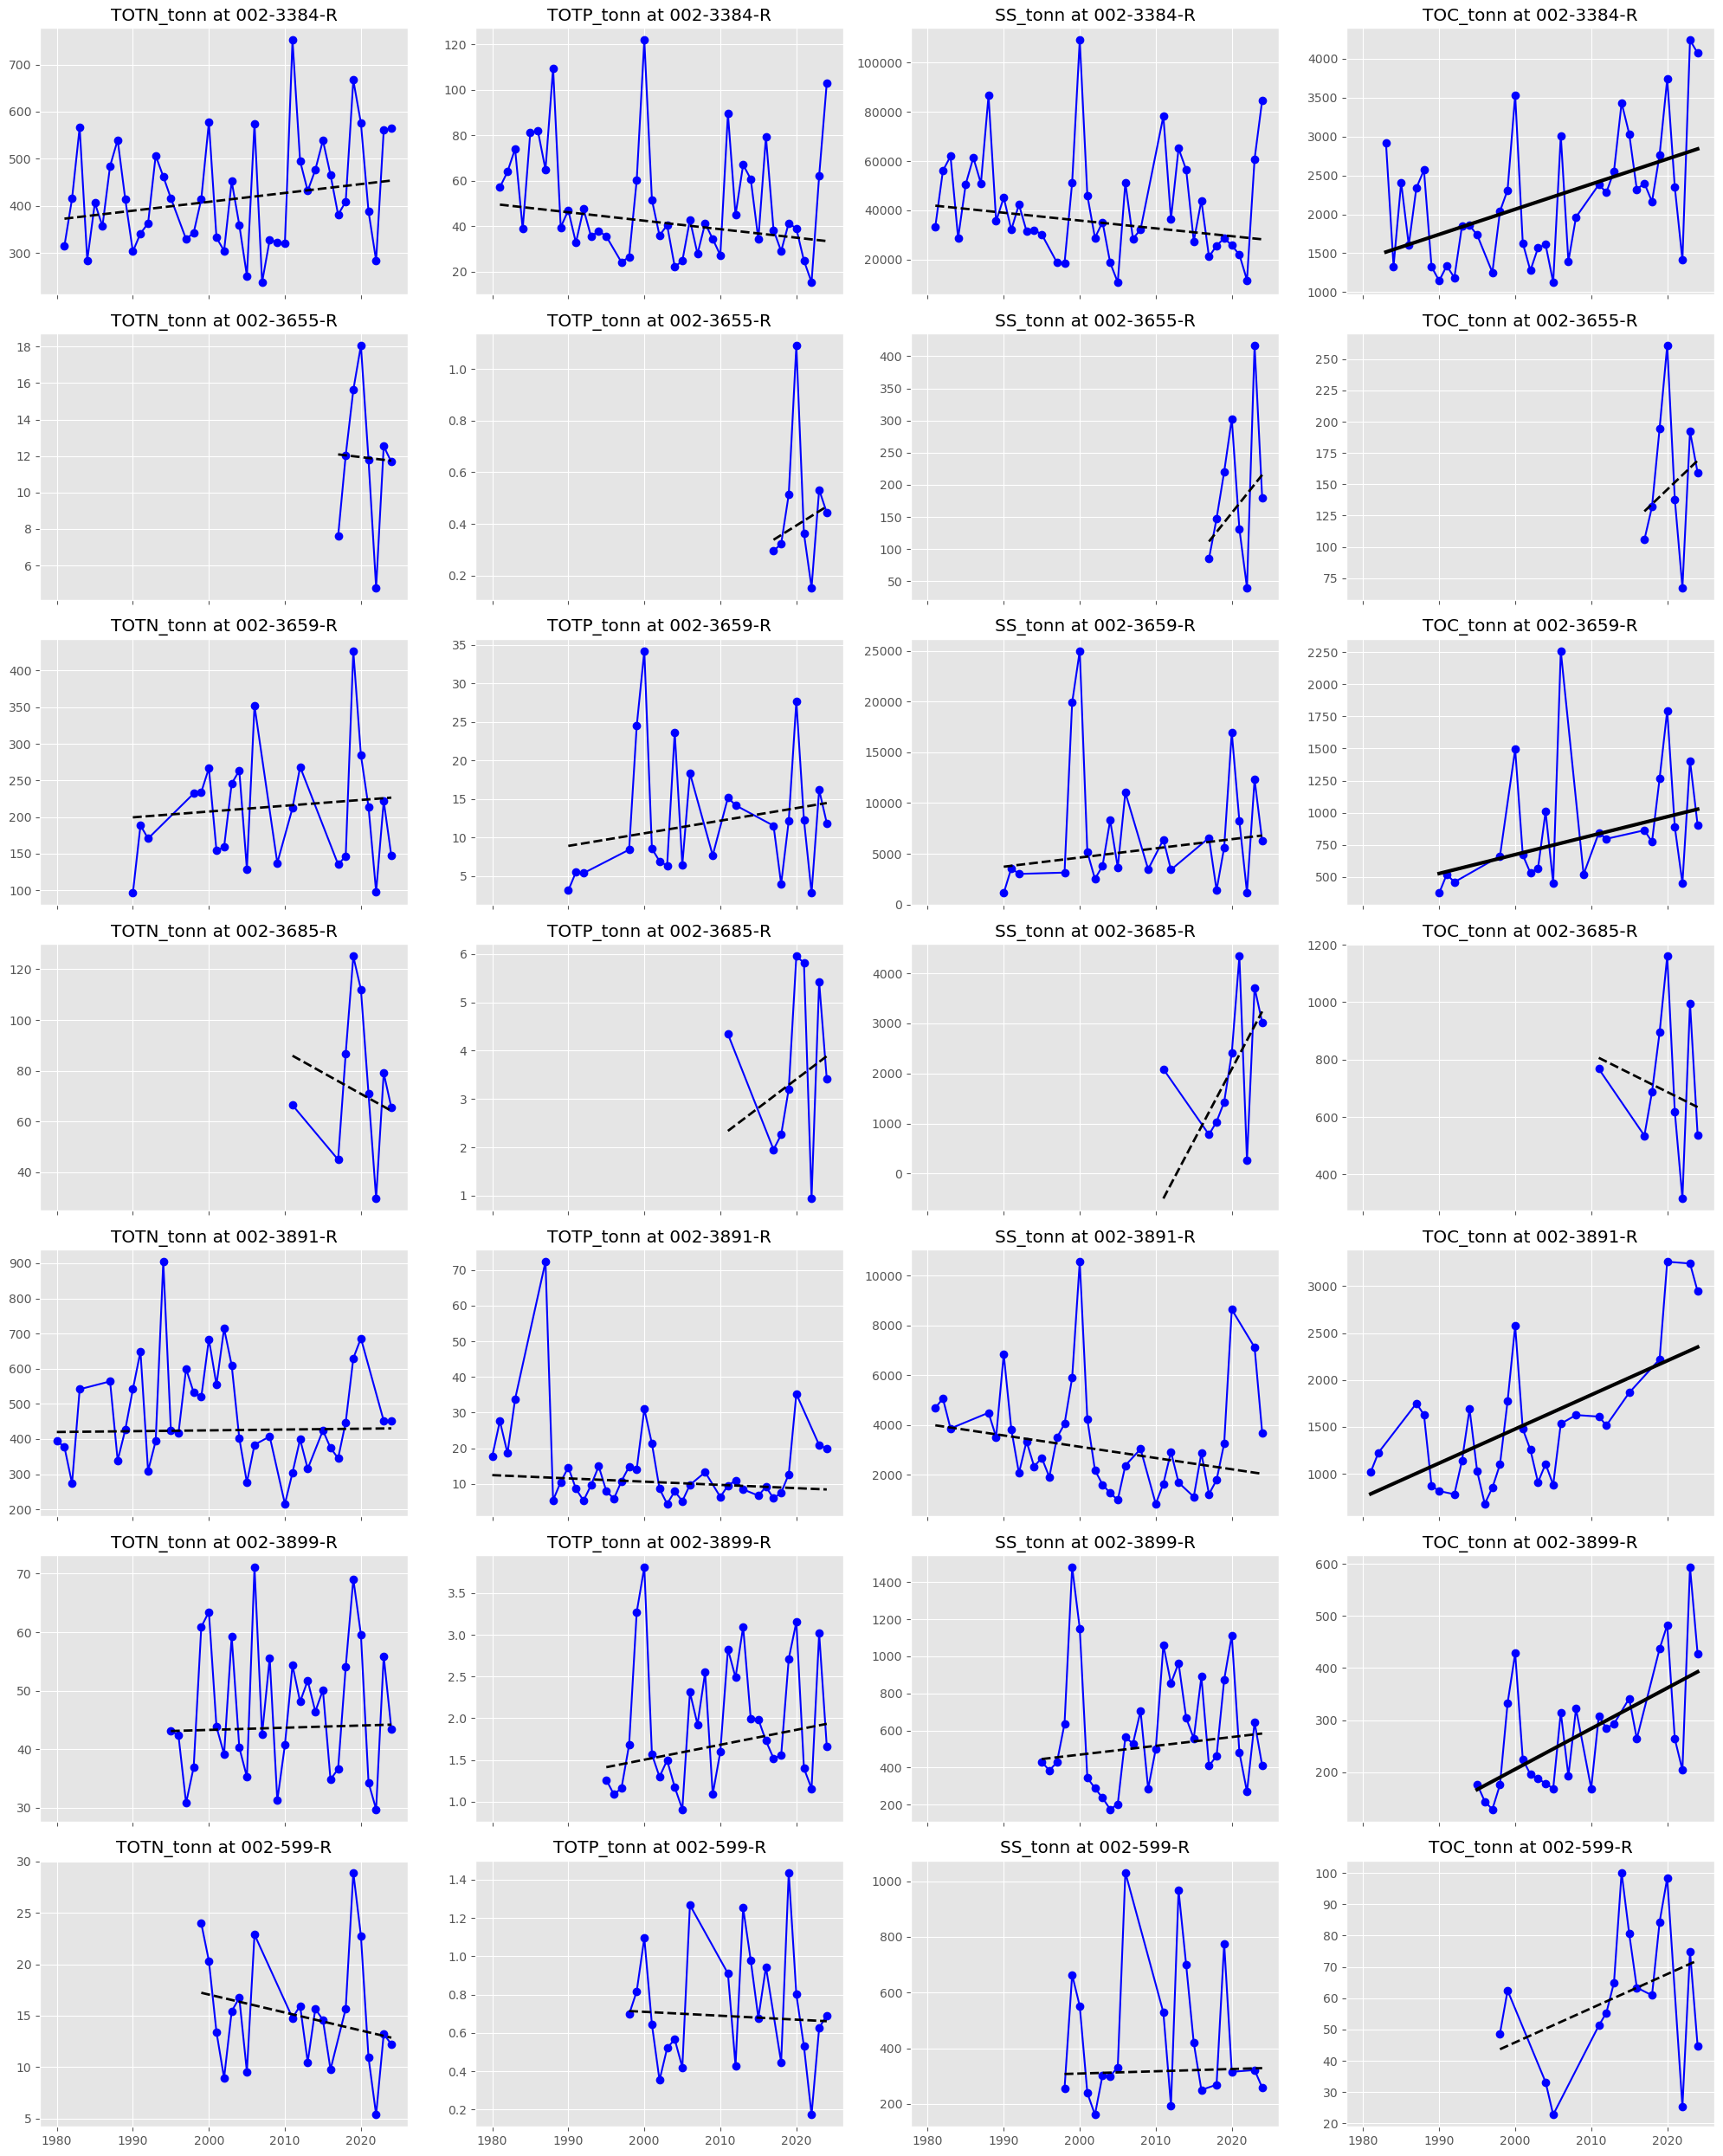

In [6]:
val_cols = ["TOTN_tonn", "TOTP_tonn", "SS_tonn", "TOC_tonn"]
fig, axes = plt.subplots(
    nrows=len(lds_df["waterbody_id"].unique()),
    ncols=4,
    figsize=(20, 25),
    sharex=True,
    sharey=False,
)

res_dict = {
    "waterbody_id": [],
    "par": [],
    "mk_trend": [],
    "mk_pval": [],
    "sslp": [],
    "sslp_ub": [],
    "sslp_lb": [],
}
for row_idx, (wb_id, wb_lds_df) in enumerate(lds_df.groupby("waterbody_id")):
    wb_lds_df = wb_lds_df.sort_values("year")
    for col_idx, par in enumerate(val_cols):
        wb_par_df = wb_lds_df[["year", par]].dropna(subset=par)

        if len(wb_par_df) > 1:
            # Test for trends
            mk_df = nivapy.stats.mk_test(wb_par_df, par, alpha=0.05)
            res_df, sen_df = nivapy.stats.sens_slope(
                wb_par_df, par, index_col="year", alpha=0.05
            )

            # Extract results
            trend = mk_df.loc["trend", "value"]
            pval = mk_df.loc["p", "value"]
            sslp = res_df.loc["sslp"]["value"]
            icpt = res_df.loc["icpt"]["value"]
            lb = res_df.loc["lb"]["value"]
            ub = res_df.loc["ub"]["value"]

            # Add to results
            res_dict["waterbody_id"].append(wb_id)
            res_dict["par"].append(par)
            res_dict["mk_trend"].append(trend)
            res_dict["mk_pval"].append(pval)
            res_dict["sslp"].append(sslp)
            res_dict["sslp_ub"].append(ub)
            res_dict["sslp_lb"].append(lb)

            # Plot
            axes[row_idx, col_idx].plot(wb_par_df["year"], wb_par_df[par], "bo-")
            if trend != "no trend":
                axes[row_idx, col_idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "k-",
                    lw=3,
                )
            else:
                axes[row_idx, col_idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "k--",
                    lw=2,
                )
            axes[row_idx, col_idx].set_title(f"{par} at {wb_id}")

    plt.tight_layout()
png_path = r"../plots/loads/all_waterbodies_ann_loads.png"
plt.savefig(png_path, dpi=200, bbox_inches="tight")

# Merge results
stat_df = pd.DataFrame(res_dict)
stat_df = pd.merge(
    stn_df[["catchment", "wb_id", "wb_name"]].drop_duplicates(),
    stat_df,
    how="right",
    left_on="wb_id",
    right_on="waterbody_id",
)
del stat_df["waterbody_id"]

stat_df

In [7]:
# Save
xl_path = r"../data/annual_loads_waterbodies.xlsx"
with pd.ExcelWriter(xl_path) as writer:
    lds_df.to_excel(writer, sheet_name="annual_loads", index=False)
    stat_df.to_excel(writer, sheet_name="load_trends", index=False)